In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 16               # 본문 크기
mpl.rcParams['axes.labelsize'] = 18         # 축 라벨
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['mathtext.fontset'] = 'cm'      # LaTeX 수식은 Computer Modern 유지
mpl.rcParams['axes.linewidth'] = 1.0   

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def poisson_kernel(theta, r, psi=0.0):
    """
    OA subpopulation density centered at psi.
    
    f(theta) = (1-r^2) / [2π(1 - 2r cos(theta-psi) + r^2)]
    
    r=1 corresponds to a delta peak, so for plotting use r slightly smaller
    than 1, e.g. r=0.995.
    """
    th = theta - psi
    return (1 - r**2) / (2 * np.pi * (1 - 2*r*np.cos(th) + r**2))


def dist_bimodal_mixture(theta, r, eta, psi=0.0):
    """
    Current bimodal OA distribution using the paper's eta convention.

    This version matches the closed-form expression with coefficient (1-2*eta).
    Peaks are located at psi and psi+pi.

    eta = 0.5  -> symmetric bimodal distribution, R=0
    eta != 0.5 -> symmetry-broken bimodal distribution, R=(1-2*eta)r
    """
    f_plus = poisson_kernel(theta, r, psi=psi)
    f_minus = poisson_kernel(theta, r, psi=psi + np.pi)

    # This weighting gives the odd harmonic coefficient (1 - 2*eta)
    f = (1 - eta) * f_plus + eta * f_minus
    return np.real(f)


def dist_bimodal_closed(theta, r, eta, psi=0.0):
    """
    Closed-form density corresponding to Eq. (S7).

    f = 1/(2π) * [1 + 2{(1-2η)r(1-r^2)cos(θ-ψ)
                      + r^2 cos(2(θ-ψ)) - r^4}
                     /(1 - 2r^2 cos(2(θ-ψ)) + r^4)]
    """
    th = theta - psi
    c1 = np.cos(th)
    c2 = np.cos(2 * th)

    den = 1 - 2 * r**2 * c2 + r**4
    num = (1 - 2*eta) * r * (1 - r**2) * c1 + r**2 * c2 - r**4

    f = (1 / (2 * np.pi)) * (1 + 2 * num / den)
    return np.real(f)

In [14]:
x = np.linspace(-np.pi/2, 3*np.pi/2, 50000)
r1_plot = 0.99999
pdf1 = dist_bimodal_closed(x, r1_plot, eta1, psi=0.0)

([<matplotlib.axis.XTick at 0x1d3e9256550>,
 [Text(0.0, 0, '0'), Text(3.141592653589793, 0, '$\\pi$')])

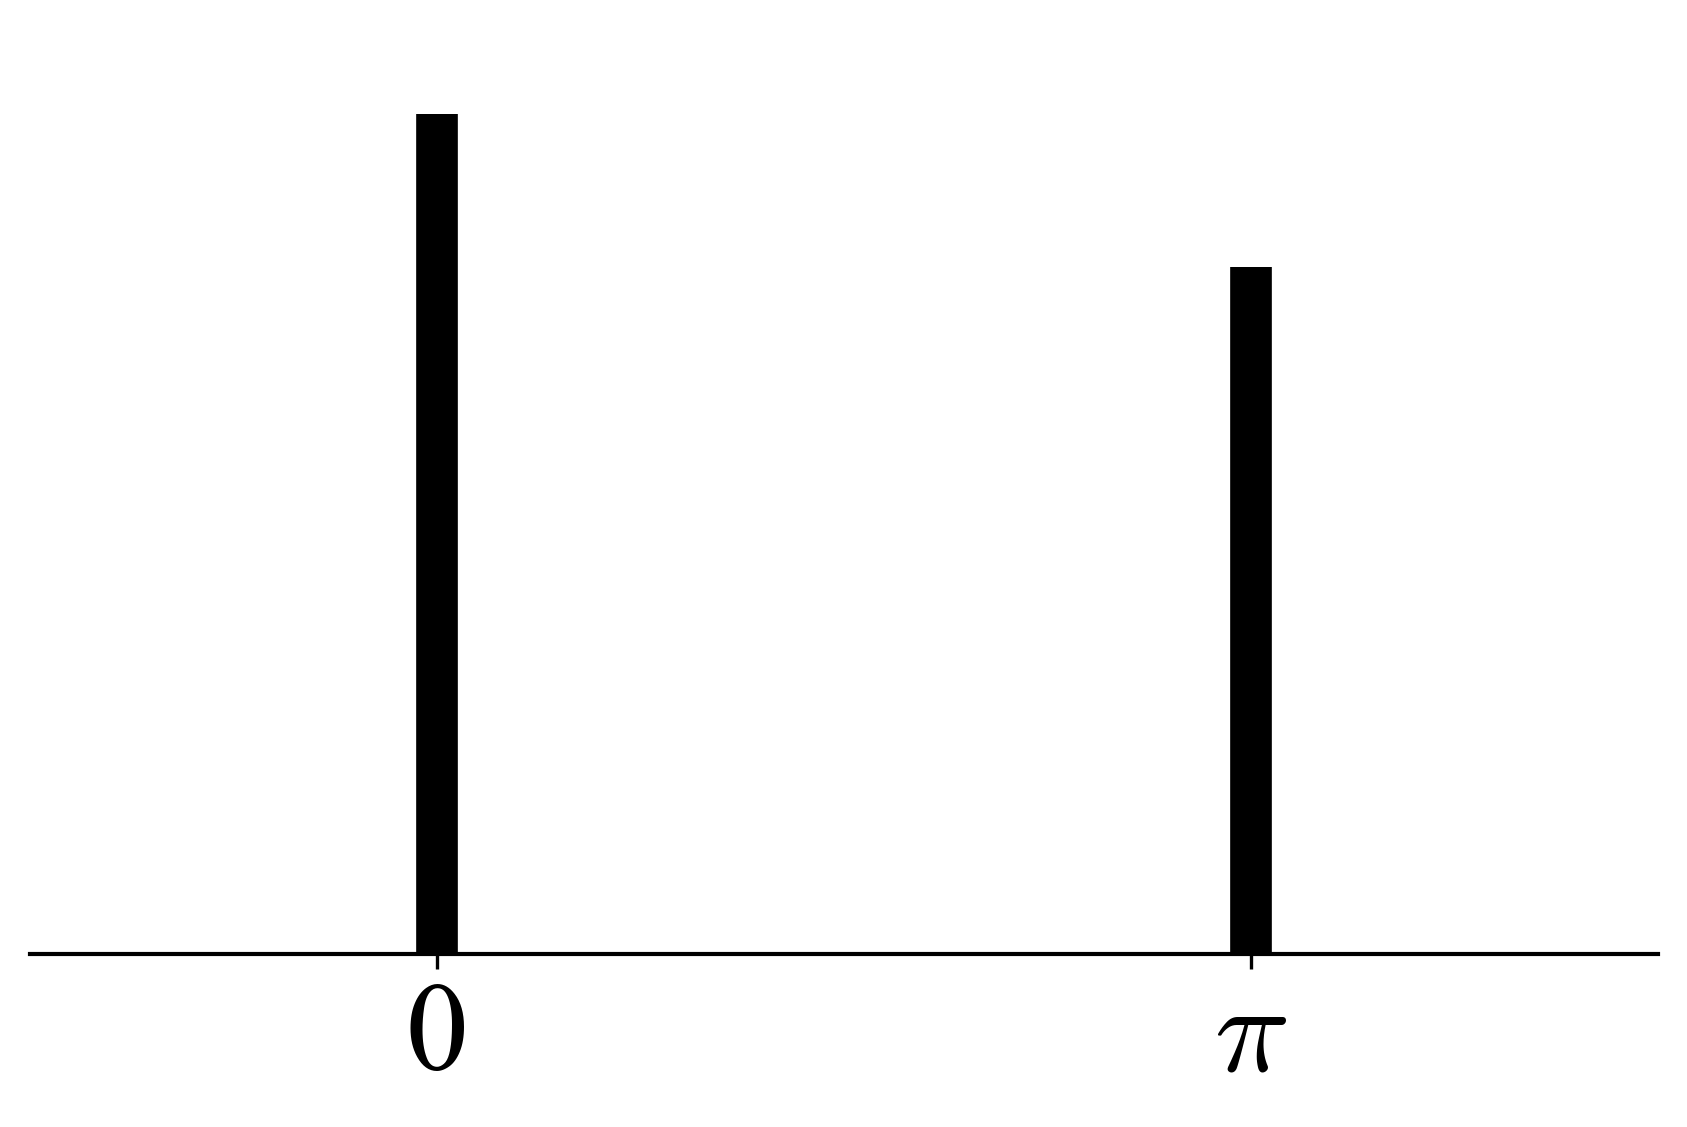

In [36]:
eta1 = 0.45

# 두 peak의 상대 weight
w0 = 1 - eta1   # at theta = 0
wpi = eta1      # at theta = pi

weights = np.array([w0, wpi])
weights = weights / np.max(weights)
plt.figure(figsize=(7,4),dpi=300)
plt.vlines([0, np.pi], [0, 0], weights, color='black', lw=10)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.yticks([])
plt.ylim(0,1.1)
plt.xlim(-np.pi/2,3*np.pi/2)
plt.xticks([0,np.pi],[0,r'$\pi$'],fontsize=30)

([<matplotlib.axis.XTick at 0x1d3e52156d0>,
 [Text(0.0, 0, '0'), Text(3.141592653589793, 0, '$\\pi$')])

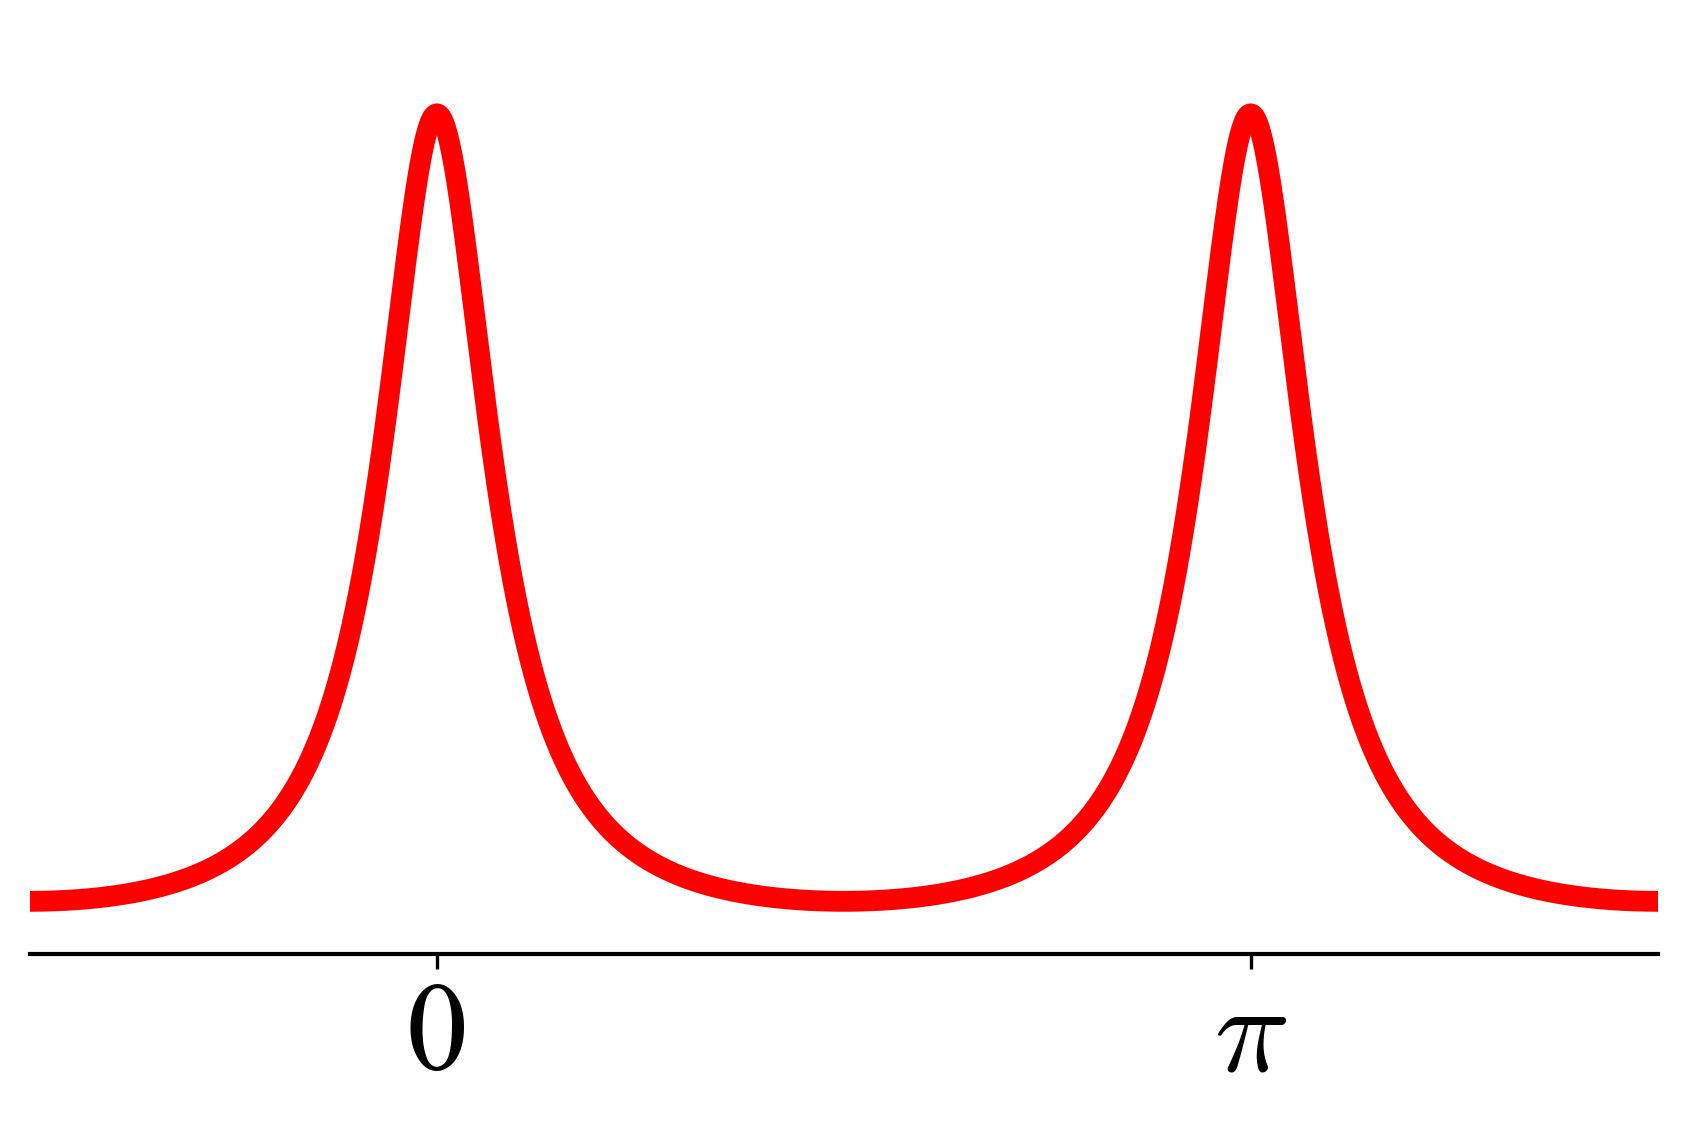

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def dist_bimodal_closed(theta, r, eta, psi=0.0):
    th = theta - psi
    den = 1 - 2*r**2*np.cos(2*th) + r**4
    num = (1 - 2*eta)*r*(1 - r**2)*np.cos(th) + r**2*np.cos(2*th) - r**4
    f = (1/(2*np.pi)) * (1 + 2*num/den)
    return np.real(f)

x = np.linspace(-np.pi/2, 3*np.pi/2, 200000)

eta2 = 0.5
Q2 = 0.6
r2 = np.sqrt(Q2)

pdf2 = dist_bimodal_closed(x, r2, eta2)
pdf2 = pdf2 / np.max(pdf2)
plt.figure(figsize=(7,4),dpi=300)

plt.plot(x, pdf2, color='red', lw=5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.yticks([])
plt.ylim(0,1.1)
plt.xlim(-np.pi/2,3*np.pi/2)
plt.xticks([0,np.pi],[0,r'$\pi$'],fontsize=30)